# Steel Surface Defect Detection — Complete Google Colab Notebook

This notebook combines three particial notebooks into one end-to-end workflow:

1. **NEU-DET dataset download and preparation**
2. **OpenCV preprocessing and contour feature extraction**
3. **EfficientNet-B0 defect classification**
4. **YOLOv8 defect localization**
5. **Evaluation, confusion matrix and prediction images**

### Six defect classes
`crazing`, `inclusion`, `patches`, `pitted_surface`, `rolled-in_scale`, `scratches`

### Before running
In Colab choose **Runtime → Change runtime type → T4 GPU → Save**. Then run cells from top to bottom.


## 1. Install libraries and import packages

We install the packages needed for OpenCV, PyTorch/EfficientNet and YOLOv8.


In [24]:
!pip install --upgrade --no-cache-dir gdown -q
!pip install ultralytics -q

import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: False


# PART A — DATASET

## 2. Download the NEU-DET dataset

Your original notebooks use `gdown` with this Google Drive file ID:

`1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj`

It downloads `archive.zip`. We download it **once** and reuse it for all three pipelines.


In [25]:
if not os.path.exists('/content/archive.zip'):
    !gdown 1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj
else:
    print('archive.zip already exists; skipping download.')


archive.zip already exists; skipping download.


## 3. Extract the dataset

Expected structure:

```text
/content/dataset/NEU-DET/
├── IMAGES/
└── ANNOTATIONS/
```


In [26]:
ROOT = Path('/content/dataset/NEU-DET')

if not ROOT.exists():
    !unzip -q /content/archive.zip -d /content/dataset
else:
    print('Dataset already extracted; skipping unzip.')

IMG_DIR = ROOT / 'IMAGES'
ANN_DIR = ROOT / 'ANNOTATIONS'

print('Images:', len(list(IMG_DIR.glob('*.jpg'))))
print('Annotations:', len(list(ANN_DIR.glob('*.xml'))))


Dataset already extracted; skipping unzip.
Images: 1800
Annotations: 1800


# PART B — OPENCV PREPROCESSING & FEATURE EXTRACTION

## 4. Read Pascal VOC XML annotations

The XML files contain the image name, defect class and bounding-box coordinates.


In [27]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename += ".jpg"

    objects = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "label": label,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return filename, objects

## 5. OpenCV preprocessing

Pipeline:

`Grayscale → CLAHE → Gaussian Blur → Otsu Threshold → Morphological Opening → Morphological Closing`

- **CLAHE:** improves local contrast.
- **Gaussian Blur:** reduces noise.
- **Otsu:** automatically chooses a threshold for binary segmentation.
- **Opening:** removes small noise.
- **Closing:** fills small gaps and connects regions.


In [28]:
def preprocess_image(img):
    # img is grayscale

    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img)

    # Denoising / smoothing
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    return enhanced, blurred
def segment_defect(img):
    enhanced, blurred = preprocess_image(img)

    # Otsu thresholding
    _, thresh = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological cleaning
    kernel = np.ones((3, 3), np.uint8)

    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

    return enhanced, blurred, thresh, closed

## 6. Extract contour features

For each detected contour we calculate area, perimeter, bounding-box coordinates, width, height, aspect ratio and circularity.


In [79]:
def extract_contour_features(mask):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    features = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 10:
            continue

        perimeter = cv2.arcLength(contour, True)

        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = w / h if h != 0 else 0

        circularity = 0
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)

        features.append({
            "area": area,
            "perimeter": perimeter,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "aspect_ratio": aspect_ratio,
            "circularity": circularity
        })

    return features, contours

## 7. Visualize one image through the entire OpenCV pipeline

The final plot shows Original, CLAHE, Gaussian Blur, Otsu Threshold, Morphology Mask and Contours + Ground Truth.


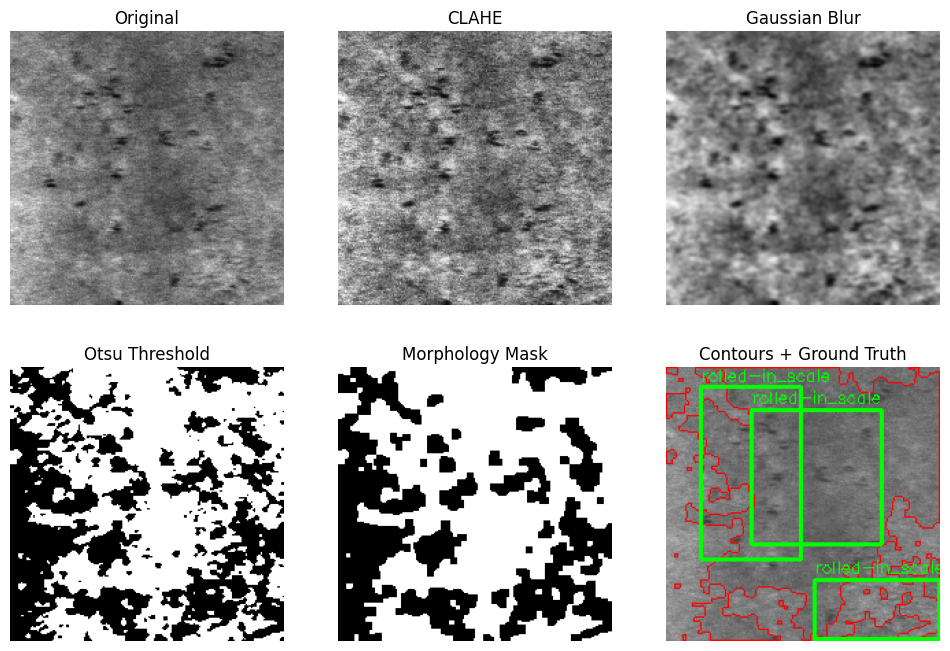

Extracted features:


,area,perimeter,x,y,w,h,aspect_ratio,circularity
0,68.5,51.071068,178,193,22,7,3.142857,0.330028
1,16.5,22.242641,82,170,7,7,1.000000,0.419103
2,789.5,235.154328,126,164,67,36,1.861111,0.179414
3,11.5,13.414214,144,162,5,4,1.250000,0.803114
4,33.5,24.242641,156,161,6,9,0.666667,0.716300


In [30]:
xml_files = list(ANN_DIR.glob("*.xml"))
sample_xml = random.choice(xml_files)

filename, objects = parse_voc_xml(sample_xml)
img_path = IMG_DIR / filename

img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

enhanced, blurred, thresh, mask = segment_defect(img)
features, contours = extract_contour_features(mask)

vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

cv2.drawContours(vis, contours, -1, (255, 0, 0), 1)

for obj in objects:
    xmin, ymin, xmax, ymax = obj["bbox"]
    label = obj["label"]
    cv2.rectangle(vis, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(vis, label, (xmin, max(ymin - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(thresh, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask, cmap="gray")
plt.title("Morphology Mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(vis)
plt.title("Contours + Ground Truth")
plt.axis("off")

plt.show()

print("Extracted features:")
pd.DataFrame(features).head()

## 8. Extract features from all 1,800 images

This produces a Pandas DataFrame containing the contour-level features and the original defect label.


In [31]:
all_features = []

for xml_path in xml_files:
    filename, objects = parse_voc_xml(xml_path)
    img_path = IMG_DIR / filename

    if not img_path.exists():
        continue

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    enhanced, blurred, thresh, mask = segment_defect(img)
    features, contours = extract_contour_features(mask)

    true_label = objects[0]["label"] if len(objects) > 0 else "unknown"

    for feat in features:
        feat["filename"] = filename
        feat["true_label"] = true_label
        all_features.append(feat)

features_df = pd.DataFrame(all_features)

features_df.head()

,area,perimeter,x,y,w,h,aspect_ratio,circularity,filename,true_label
0,54.0,45.656854,193,181,7,19,0.368421,0.325530,pitted_surface_203.jpg,pitted_surface
1,69.5,61.556349,49,159,9,23,0.391304,0.230488,pitted_surface_203.jpg,pitted_surface
2,14.5,15.414214,111,133,6,4,1.500000,0.766894,pitted_surface_203.jpg,pitted_surface
3,22.5,21.071068,131,132,6,8,0.750000,0.636824,pitted_surface_203.jpg,pitted_surface
4,443.0,113.941125,177,130,23,37,0.621622,0.428798,pitted_surface_203.jpg,pitted_surface


## 9. Save the OpenCV feature CSV


In [32]:
features_df.to_csv("/content/opencv_extracted_features.csv", index=False)

print("Saved:", "/content/opencv_extracted_features.csv")
print("Number of extracted regions:", len(features_df))

Saved: /content/opencv_extracted_features.csv
Number of extracted regions: 18659


# PART C — EFFICIENTNET-B0 CLASSIFICATION

## 10. Build the classification dataset

We convert the XML labels into an `ImageFolder` directory structure with `train`, `val` and `test` folders. The original project uses a stratified 70% / 15% / 15% split inside each defect class.


### 10.1 Read labels from XML

In [33]:
def parse_voc_xml_for_classification(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename += ".jpg"

    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        labels.append(label)

    return filename, labels

### 10.2 Create train/val/test folders

In [34]:
CLS_ROOT = Path("/content/neu_classification")

if CLS_ROOT.exists():
    shutil.rmtree(CLS_ROOT)

for split in ["train", "val", "test"]:
    (CLS_ROOT / split).mkdir(parents=True, exist_ok=True)

In [35]:
samples = []

for xml_path in ANN_DIR.glob("*.xml"):
    filename, labels = parse_voc_xml_for_classification(xml_path)

    if len(labels) == 0:
        continue

    img_path = IMG_DIR / filename

    if not img_path.exists():
        continue

    # Most NEU-DET images contain defects from one class.
    label = labels[0]

    samples.append((img_path, label))

print("Total samples:", len(samples))
print(samples[:5])

Total samples: 1800
[(PosixPath('/content/dataset/NEU-DET/IMAGES/pitted_surface_203.jpg'), 'pitted_surface'), (PosixPath('/content/dataset/NEU-DET/IMAGES/patches_109.jpg'), 'patches'), (PosixPath('/content/dataset/NEU-DET/IMAGES/patches_274.jpg'), 'patches'), (PosixPath('/content/dataset/NEU-DET/IMAGES/inclusion_203.jpg'), 'inclusion'), (PosixPath('/content/dataset/NEU-DET/IMAGES/inclusion_230.jpg'), 'inclusion')]


### 10.3 Stratified 70/15/15 split

In [36]:
from collections import defaultdict

by_class = defaultdict(list)

for img_path, label in samples:
    by_class[label].append((img_path, label))

train_samples, val_samples, test_samples = [], [], []

random.seed(42)

for label, items in by_class.items():
    random.shuffle(items)
    n = len(items)

    train_samples.extend(items[:int(0.7*n)])
    val_samples.extend(items[int(0.7*n):int(0.85*n)])
    test_samples.extend(items[int(0.85*n):])

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

Train: 1260
Val: 270
Test: 270


In [37]:
splits = {
    "train": train_samples,
    "val": val_samples,
    "test": test_samples
}

for split, split_samples in splits.items():
    for img_path, label in split_samples:
        class_dir = CLS_ROOT / split / label
        class_dir.mkdir(parents=True, exist_ok=True)

        dst = class_dir / img_path.name
        shutil.copy(img_path, dst)

In [38]:
!find /content/neu_classification -maxdepth 2 -type d

/content/neu_classification
/content/neu_classification/test
/content/neu_classification/test/scratches
/content/neu_classification/test/inclusion
/content/neu_classification/test/pitted_surface
/content/neu_classification/test/rolled-in_scale
/content/neu_classification/test/crazing
/content/neu_classification/test/patches
/content/neu_classification/val
/content/neu_classification/val/scratches
/content/neu_classification/val/inclusion
/content/neu_classification/val/pitted_surface
/content/neu_classification/val/rolled-in_scale
/content/neu_classification/val/crazing
/content/neu_classification/val/patches
/content/neu_classification/train
/content/neu_classification/train/scratches
/content/neu_classification/train/inclusion
/content/neu_classification/train/pitted_surface
/content/neu_classification/train/rolled-in_scale
/content/neu_classification/train/crazing
/content/neu_classification/train/patches


### 10.4 Check GPU

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cpu


### 10.5 Image transforms

In [40]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 10.6 PyTorch datasets

In [41]:
train_dataset = datasets.ImageFolder(CLS_ROOT / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(CLS_ROOT / "val", transform=eval_transform)
test_dataset = datasets.ImageFolder(CLS_ROOT / "test", transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [42]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

### 10.7 Load pretrained EfficientNet-B0 and replace the final classifier

In [43]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

### 10.8 Loss function and optimizer

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

### 10.9 Training function

In [45]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

### 10.10 Evaluation function

In [46]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return total_loss / total, correct / total, y_true, y_pred

### 10.11 Train for 5 epochs and save the best validation model

In [47]:
best_val_acc = 0
best_model_path = "/content/efficientnet_b0_neu_classification.pt"

epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best Val Accuracy:", best_val_acc)

Epoch 1/5
Train Loss: 1.1467 | Train Acc: 0.7452
Val Loss:   0.9143 | Val Acc:   0.8593
----------------------------------------
Epoch 2/5
Train Loss: 0.4640 | Train Acc: 0.9516
Val Loss:   0.4808 | Val Acc:   0.9556
----------------------------------------
Epoch 3/5
Train Loss: 0.2791 | Train Acc: 0.9579
Val Loss:   0.2914 | Val Acc:   0.9667
----------------------------------------
Epoch 4/5
Train Loss: 0.2398 | Train Acc: 0.9579
Val Loss:   0.2124 | Val Acc:   0.9741
----------------------------------------
Epoch 5/5
Train Loss: 0.1778 | Train Acc: 0.9627
Val Loss:   0.1757 | Val Acc:   0.9778
----------------------------------------
Best Val Accuracy: 0.9777777777777777


### 10.12 Test the best model

In [48]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9777777777777777


### 10.13 Classification report

In [49]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        45
      inclusion     0.9149    0.9556    0.9348        45
        patches     1.0000    1.0000    1.0000        45
 pitted_surface     1.0000    1.0000    1.0000        45
rolled-in_scale     1.0000    1.0000    1.0000        45
      scratches     0.9535    0.9111    0.9318        45

       accuracy                         0.9778       270
      macro avg     0.9781    0.9778    0.9778       270
   weighted avg     0.9781    0.9778    0.9778       270



### 10.14 Confusion matrix

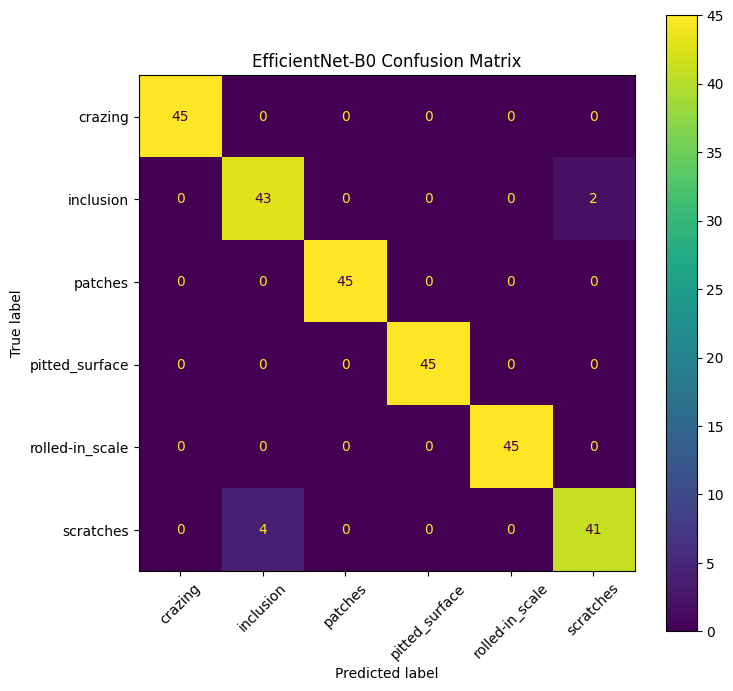

In [50]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()

### 10.15 Download the trained EfficientNet model

In [51]:
from google.colab import files
files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PART D — YOLOv8 LOCALIZATION

## 11. Prepare YOLO dataset

YOLO needs integer class IDs and normalized bounding boxes. We convert the original Pascal VOC XML annotations into YOLO `.txt` files.


### 11.1 Parse XML and inspect one bounding box

In [52]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    # Some XML files have filenames without extension
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename = filename + ".jpg"

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    objects = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "label": label,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return filename, width, height, objects

### 11.2 Discover the six classes and assign class IDs

In [53]:
classes = set()

for xml_path in ANN_DIR.glob("*.xml"):
    _, _, _, objects = parse_voc_xml(xml_path)
    for obj in objects:
        classes.add(obj["label"])

classes = sorted(list(classes))
class_to_id = {cls: i for i, cls in enumerate(classes)}

print(classes)
print(class_to_id)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


### 11.3 Create YOLO folders

In [54]:
YOLO_ROOT = Path("/content/neu_yolo")
for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

### 11.4 Split annotations 70/15/15

In [55]:
xml_files = list(ANN_DIR.glob("*.xml"))
random.seed(42)
random.shuffle(xml_files)

n = len(xml_files)
train_files = xml_files[:int(0.7*n)]
val_files = xml_files[int(0.7*n):int(0.85*n)]
test_files = xml_files[int(0.85*n):]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

print(len(train_files), len(val_files), len(test_files))

1260 270 270


### 11.5 Convert VOC coordinates to YOLO normalized coordinates

In [56]:
def voc_to_yolo_bbox(bbox, img_w, img_h):
    xmin, ymin, xmax, ymax = bbox

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    box_w = (xmax - xmin) / img_w
    box_h = (ymax - ymin) / img_h

    return x_center, y_center, box_w, box_h

### 11.6 Convert all XML annotations to YOLO `.txt` labels

In [57]:
for split, files in splits.items():
    for xml_path in files:
        filename, width, height, objects = parse_voc_xml(xml_path)

        src_img = IMG_DIR / filename
        dst_img = YOLO_ROOT / "images" / split / filename
        shutil.copy(src_img, dst_img)

        label_filename = Path(filename).stem + ".txt"
        dst_label = YOLO_ROOT / "labels" / split / label_filename

        with open(dst_label, "w") as f:
            for obj in objects:
                class_id = class_to_id[obj["label"]]
                x, y, w, h = voc_to_yolo_bbox(obj["bbox"], width, height)
                f.write(f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

### 11.7 Create `neu_det.yaml`

In [58]:
yaml_content = f"""
path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

names:
"""

for i, cls in enumerate(classes):
    yaml_content += f"  {i}: {cls}\n"

yaml_path = YOLO_ROOT / "neu_det.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /content/neu_yolo
train: images/train
val: images/val
test: images/test

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



### 11.8 Train YOLOv8n

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=200,
    batch=16,
    patience=10,
    project="/content/runs",
    name="neu_yolov8n"
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/neu_yolo/neu_det.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=No

### 11.9 Evaluate on the test set

In [72]:
model = YOLO("/content/runs/neu_yolov8n/weights/best.pt")

metrics = model.val(
    data=str(yaml_path),
    split="test",
    imgsz=200
)

WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 669.5±373.9 MB/s, size: 16.0 KB)
val: Scanning /content/neu_yolo/labels/test.cache... 270 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 270/270 51.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.5it/s 6.9s
                   all        270        643      0.715      0.666      0.721      0.421
               crazing         45        104      0.641      0.137      0.372      0.133
             inclusion         69        185       0.78      0.757      0.827      0.438
               patches         45        121      0.812      0.931      0.925      0.594
        pitted_surface         42         56      0.695      0.714      

### 11.10 Run inference on test images


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/crazing_88.jpg: 224x224 1 crazing, 35.6ms
Speed: 1.4ms preprocess, 35.6ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 224)


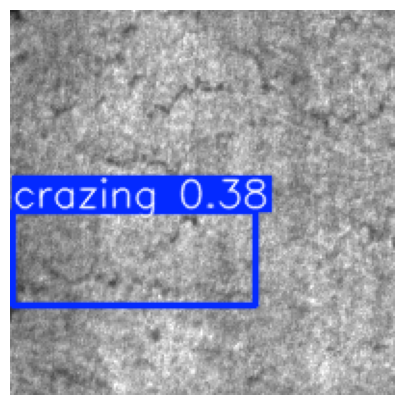


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/pitted_surface_77.jpg: 224x224 3 pitted_surfaces, 37.2ms
Speed: 2.3ms preprocess, 37.2ms inference, 0.7ms postprocess per image at shape (1, 3, 224, 224)


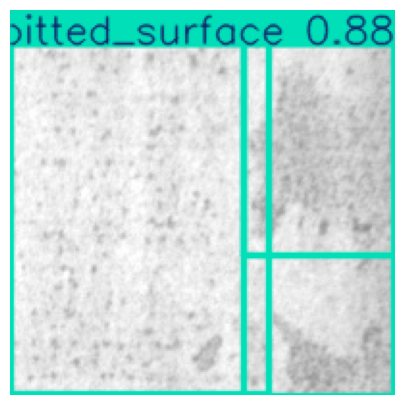


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/inclusion_200.jpg: 224x224 2 inclusions, 28.9ms
Speed: 1.5ms preprocess, 28.9ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 224)


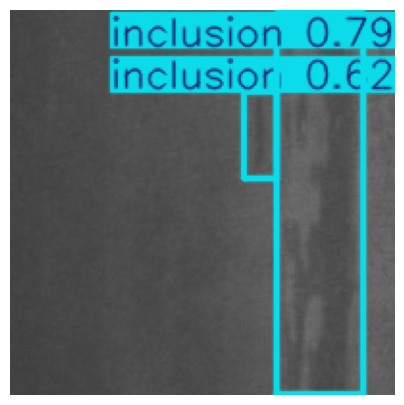


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/scratches_278.jpg: 224x224 6 scratchess, 28.6ms
Speed: 1.0ms preprocess, 28.6ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 224)


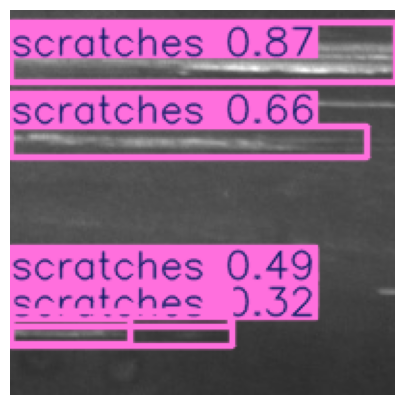


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/rolled-in_scale_282.jpg: 224x224 1 rolled-in_scale, 30.1ms
Speed: 1.1ms preprocess, 30.1ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 224)


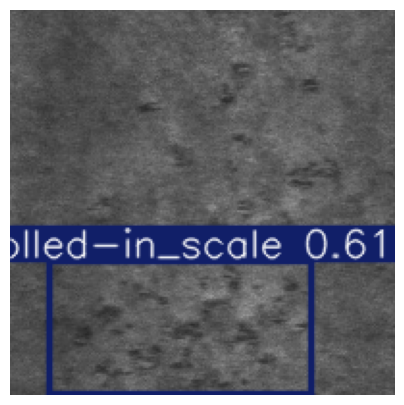

In [70]:
test_images = list((YOLO_ROOT / "images" / "test").glob("*.jpg"))[:5]

for img_path in test_images:
    results = model.predict(
        source=str(img_path),
        imgsz=200,
        conf=0.25
    )

    plotted = results[0].plot()
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

### 11.11 Print YOLO metrics

In [71]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.mp)
print(metrics.box.mr)

0.4206724058095679
0.7205648843705678
0.7147434962062521
0.6664731161121671


### 11.12 Store metrics in a dictionary

In [73]:
results_summary = {
    "model": "YOLOv8n",
    "mAP50": metrics.box.map50,
    "mAP50_95": metrics.box.map,
    "precision": metrics.box.mp,
    "recall": metrics.box.mr
}

results_summary

{'model': 'YOLOv8n',
 'mAP50': np.float64(0.7205648843705678),
 'mAP50_95': np.float64(0.4206724058095679),
 'precision': np.float64(0.7147434962062521),
 'recall': np.float64(0.6664731161121671)}

### 11.13 Save predictions for the whole test set

In [74]:
output_dir = "/content/yolo_predictions"

results = model.predict(
    source=str(YOLO_ROOT / "images" / "test"),
    imgsz=200,
    conf=0.25,
    save=True,
    project=output_dir,
    name="predictions"
)


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/270 /content/neu_yolo/images/test/crazing_10.jpg: 224x224 (no detections), 24.2ms
image 2/270 /content/neu_yolo/images/test/crazing_104.jpg: 224x224 1 crazing, 1 patches, 22.1ms
image 3/270 /content/neu_yolo/images/test/crazing_11.jpg: 224x224 1 crazing, 22.3ms
image 4/270 /content/neu_yolo/images/test/crazing_111.jpg: 224x224 (no detections), 22.3ms
image 5/270 /content/neu_yolo/images/test/crazing_114.jpg: 224x224 1 crazing, 23.1ms
image 6/270 /content/neu_yolo/images/test/crazing_125.jpg: 224x224 1 crazing, 21.7ms
image 7/270 /content/neu_yolo/images/test/crazing_133.jpg: 224x224 1 crazing, 21.7ms
image 8/270 /content/neu_yolo/images/test/crazing_137.jpg: 224x224 1 crazing, 21.6ms
image 9/270 /content/neu_yolo/images/test/crazing_155.jpg: 224x224 (no detections), 26.0ms
image 10/270 /content/neu_yolo/images/test/crazing_158.jpg: 224x224 (no detections), 27.2ms
image 11/270 /content/neu_yolo/images/t

### 11.14 Copy the best YOLO weights

In [75]:
import shutil

shutil.copy(
    "/content/runs/neu_yolov8n/weights/best.pt",
    "/content/yolov8n_neu_defect_best.pt"
)

'/content/yolov8n_neu_defect_best.pt'

### 11.15 Download the trained YOLO model

In [76]:
from google.colab import files
files.download("/content/yolov8n_neu_defect_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 11.16 Zip prediction images

In [77]:
!zip -r yolo_predictions.zip /content/yolo_predictions

updating: content/yolo_predictions/ (stored 0%)
updating: content/yolo_predictions/predictions/ (stored 0%)
updating: content/yolo_predictions/predictions/crazing_88.jpg (deflated 1%)
updating: content/yolo_predictions/predictions/pitted_surface_77.jpg (deflated 2%)
updating: content/yolo_predictions/predictions/inclusion_200.jpg (deflated 2%)
updating: content/yolo_predictions/predictions/scratches_278.jpg (deflated 2%)
updating: content/yolo_predictions/predictions/rolled-in_scale_282.jpg (deflated 1%)
updating: content/yolo_predictions/predictions/scratches_129.jpg (deflated 5%)
updating: content/yolo_predictions/predictions/crazing_275.jpg (deflated 1%)
updating: content/yolo_predictions/predictions/patches_254.jpg (deflated 1%)
updating: content/yolo_predictions/predictions/rolled-in_scale_90.jpg (deflated 1%)
updating: content/yolo_predictions/predictions/pitted_surface_244.jpg (deflated 3%)
updating: content/yolo_predictions/predictions/rolled-in_scale_153.jpg (deflated 1%)
upda

In [78]:
from google.colab import files
files.download("yolo_predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# FINAL PROJECT SUMMARY

You have built three related pipelines:

### OpenCV
`Image → preprocessing → segmentation → contours → geometric features → CSV`

### EfficientNet-B0
`Image → six-class defect classification`

### YOLOv8
`Image → defect class + bounding box + confidence`

### Main files to keep
- `opencv_extracted_features.csv`
- `efficientnet_b0_neu_classification.pt`
- `yolov8n_neu_defect_best.pt`
- `yolo_predictions.zip`
